<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/ThermodynamicsOfMineralScale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mineral-scale thermodynamics and flowline control with NeqSim

This notebook develops a reproducible mineral-scale workflow for oil and gas production.
It combines rigorous Electrolyte-CPA aqueous speciation with fast engineering screening,
incompatible-brine mixing, a temperature and pressure profile, inhibitor assessment, and a
multiphase flowline deposition calculation.

**Audience.** Flow-assurance, production-chemistry, process, and facilities engineers who know
basic phase equilibrium and Python.

**Prerequisites.** Familiarity with molar composition, aqueous-ion analyses, absolute pressure,
pH, and the distinction between thermodynamic tendency and deposition rate.

## Learning objectives

After completing the notebook, you will be able to:

1. create an electrolyte fluid and solve gas-aqueous equilibrium with NeqSim;
2. retrieve aqueous ion activities and mineral saturation ratios;
3. calculate saturation indices for carbonate and sulphate minerals;
4. locate the worst incompatible-water mixing ratio;
5. screen scale tendency along a cooling and depressurising flowline;
6. assess an inhibitor dose and a coupled hydraulic/deposition case; and
7. apply numerical, thermodynamic, and engineering validation checks.

The calculations are screening studies, not chemical-treatment qualification. Final design
requires representative water samples, validated analytical data, compatibility tests, kinetic
testing, inhibitor-residual measurements, and materials review.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    installation = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
        capture_output=True,
        text=True,
    )
    print(installation.stdout.splitlines()[-1])
else:
    print("NeqSim is available in this runtime.")

NeqSim is available in this runtime.


## Runtime and imports

NeqSim's Python package starts a Java virtual machine and exposes the released Java calculation
classes through JPype. Pandas is used only for labelled tables, and Matplotlib is used for
engineering graphics. Every pressure in this notebook is absolute.

In [2]:
import importlib.metadata
import json
import platform
import subprocess

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim.process import beggs_brill_pipe, stream
from neqsim.thermo import (
    TPflash,
    calcIonComposition,
    checkScalePotential,
    fluid,
)


neqsim_version = importlib.metadata.version("neqsim")
java_version = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True,
    check=True,
).stderr.splitlines()[0]

print(f"NeqSim version: {neqsim_version}")
print(f"Python version: {platform.python_version()}")
print(f"Java version: {java_version}")

NeqSim version: 3.16.0
Python version: 3.12.13
Java version: openjdk version "17.0.19" 2026-04-21


## Governing scale metrics

For a mineral with ion activities $a_i$ and stoichiometric coefficients $\nu_i$, the ion
activity product is

$$
IAP = \prod_i a_i^{\nu_i}
$$

Activity is written in terms of molality $m_i$ and activity coefficient $\gamma_i$:

$$
a_i = \gamma_i m_i
$$

The saturation ratio $SR$ and saturation index $SI$ are

$$
SR = \frac{IAP}{K_{sp}}
$$

$$
SI = \log_{10}(SR)
$$

Here $K_{sp}$ is the temperature- and pressure-dependent solubility product. $SI>0$ means
supersaturation is thermodynamically possible, $SI=0$ is equilibrium, and $SI<0$ means
undersaturation. Positive $SI$ does not prove that scale will deposit: nucleation, residence
time, surfaces, shear, inhibitor performance, and mass transfer also matter.

## How the NeqSim objects fit together

The calculation uses two complementary levels:

- `Electrolyte-CPA-EoS` represents hydrocarbons, water, ions, chemical reactions, phase
  equilibrium, and non-ideal aqueous activities in one thermodynamic system.
- `ScalePredictionCalculator` and `BrineMixingScaleEvaluator` provide fast water-analysis
  screening in mg/L over many operating cases.
- `FlowlineScaleProfile` maps screening indices over a temperature and pressure trajectory.
- `Stream` and `PipeBeggsAndBrills` provide a reusable process connection and hydraulic profile.
- `ScaleDepositionAccumulator` and `ClosedLoopDepositionSolver` convert a stated deposition
  scenario into wall thickness and hydraulic feedback.

This separation keeps the rigorous speciation calculation visible while making scenario sweeps
fast enough for a clean Colab runtime.

In [3]:
ScalePredictionCalculator = jpype.JClass(
    "neqsim.pvtsimulation.flowassurance.ScalePredictionCalculator"
)
FlowlineScaleProfile = jpype.JClass(
    "neqsim.pvtsimulation.flowassurance.FlowlineScaleProfile"
)
BrineComposition = jpype.JClass(
    "neqsim.process.chemistry.scale."
    "BrineMixingScaleEvaluator$BrineComposition"
)
BrineMixingScaleEvaluator = jpype.JClass(
    "neqsim.process.chemistry.scale.BrineMixingScaleEvaluator"
)
ScaleInhibitorPerformance = jpype.JClass(
    "neqsim.process.chemistry.scale.ScaleInhibitorPerformance"
)
ScaleType = jpype.JClass(
    "neqsim.process.chemistry.scale."
    "ScaleInhibitorPerformance$ScaleType"
)
InhibitorChemistry = jpype.JClass(
    "neqsim.process.chemistry.scale."
    "ScaleInhibitorPerformance$InhibitorChemistry"
)
ScaleDepositionAccumulator = jpype.JClass(
    "neqsim.process.chemistry.scale.ScaleDepositionAccumulator"
)
ClosedLoopDepositionSolver = jpype.JClass(
    "neqsim.process.chemistry.scale.ClosedLoopDepositionSolver"
)

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
}

## Workflow overview

The first figure is a reusable map from analytical inputs to an operating decision. A water
analysis is never interpreted in isolation: thermodynamic tendency, mixing, the flowline
trajectory, chemical control, and hydraulic consequences are connected.

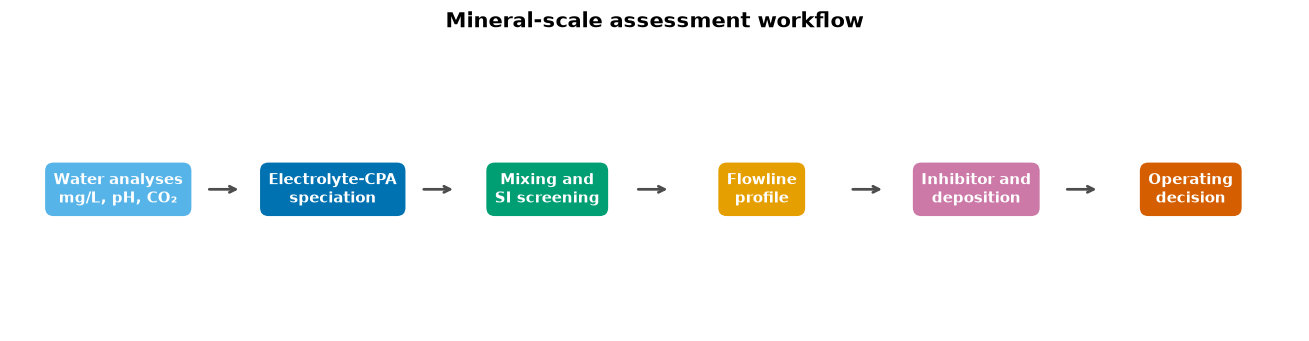

In [4]:
figure, axis = plt.subplots(figsize=(12, 3.2))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 3.0)
axis.axis("off")

labels = [
    "Water analyses\nmg/L, pH, CO₂",
    "Electrolyte-CPA\nspeciation",
    "Mixing and\nSI screening",
    "Flowline\nprofile",
    "Inhibitor and\ndeposition",
    "Operating\ndecision",
]
box_colors = [
    COLORS["sky"],
    COLORS["blue"],
    COLORS["green"],
    COLORS["orange"],
    COLORS["purple"],
    COLORS["red"],
]

for index, label in enumerate(labels):
    x_position = 0.2 + 2.0 * index
    axis.text(
        x_position + 0.8,
        1.5,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        weight="bold",
        bbox={
            "boxstyle": "round,pad=0.55",
            "facecolor": box_colors[index],
            "edgecolor": "none",
        },
    )
    if index < len(labels) - 1:
        axis.annotate(
            "",
            xy=(x_position + 1.95, 1.5),
            xytext=(x_position + 1.62, 1.5),
            arrowprops={
                "arrowstyle": "->",
                "color": "#4D4D4D",
                "lw": 1.8,
            },
        )

axis.set_title(
    "Mineral-scale assessment workflow",
    fontsize=14,
    weight="bold",
    pad=14,
)
plt.tight_layout()
plt.show()

The workflow prevents a common error: treating one positive index as a deposition forecast.
The later sections test how the same chemistry behaves when waters mix, conditions change, and
an inhibitor or hydraulic feedback is introduced.

An optional fundamentals primer is available in this
[mineral-scale lecture](https://www.youtube.com/watch?v=-ssdObbztqA&t=850s).

## Electrolyte-CPA reference fluid

The thermodynamic fluid contains a light hydrocarbon gas, water, sodium chloride, calcium,
iron, hydroxide, and the carbonate species generated by chemical equilibrium. Component
amounts are flows, so the input does not need to sum to one. The state is set to 298.15 K and
20 bara.

`chemicalReactionInit()` activates aqueous reactions. Mixing rule 10 is the electrolyte-CPA
mixing rule used by this system. `TPflash()` solves phase equilibrium and chemical equilibrium
at fixed temperature and pressure.

In [5]:
def build_electrolyte_reference():
    reference_fluid = fluid(
        "electrolyte-cpa",
        temperature=298.15,
        pressure=20.0,
    )
    gas_components = {
        "nitrogen": 1.0,
        "CO2": 1.1,
        "methane": 88.3,
        "ethane": 5.0,
        "propane": 1.5,
    }
    for component_name, molar_amount in gas_components.items():
        reference_fluid.addComponent(
            component_name,
            molar_amount,
        )

    reference_fluid.addComponent("water", 1.25, "kg/sec")
    reference_fluid.addComponent("Na+", 0.025, "mol/sec")
    reference_fluid.addComponent("Cl-", 0.025, "mol/sec")
    reference_fluid.addComponent("Ca++", 0.00025, "mol/sec")
    reference_fluid.addComponent("Fe++", 0.00025, "mol/sec")
    reference_fluid.addComponent("OH-", 0.00025, "mol/sec")
    reference_fluid.chemicalReactionInit()
    reference_fluid.setMixingRule(10)
    TPflash(reference_fluid)
    reference_fluid.initPhysicalProperties()
    return reference_fluid


electrolyte_fluid = build_electrolyte_reference()
print(f"Number of phases: {electrolyte_fluid.getNumberOfPhases()}")
print(
    "Aqueous pH: "
    f"{electrolyte_fluid.getPhase('aqueous').getpH():.4f}"
)

Number of phases: 2
Aqueous pH: 5.2061


## Inspect the calculated phases

The gas and aqueous phases are retrieved by phase name. Density is requested only after
`initPhysicalProperties()`, which avoids reading an uninitialised transport-property cache.
Phase fraction is molar.

In [6]:
phase_rows = []
for phase_name in ["gas", "aqueous"]:
    phase = electrolyte_fluid.getPhase(phase_name)
    phase_rows.append(
        {
            "phase": phase_name,
            "molar phase fraction [-]": float(phase.getBeta()),
            "density [kg/m³]": float(phase.getDensity("kg/m3")),
            "temperature [K]": float(phase.getTemperature()),
            "pressure [bara]": float(phase.getPressure()),
        }
    )

phase_table = pd.DataFrame(phase_rows)
print(phase_table.to_string(index=False, float_format=lambda value: f"{value:.6g}"))

  phase  molar phase fraction [-]  density [kg/m³]  temperature [K]  pressure [bara]
    gas                  0.577406          14.7413           298.15               20
aqueous                  0.422572          999.712           298.15               20


## Aqueous speciation and activity coefficients

`calcIonComposition()` reports concentrations per kilogram of solvent and the activity
coefficient used by the electrolyte model. The selected table retains the dissolved gases,
major ions, and carbonate species needed to interpret the scale result.

In [7]:
def java_table_to_dataframe(java_table):
    rows = []
    for java_row in java_table:
        python_row = []
        for value in java_row:
            if value is None:
                python_row.append(None)
            else:
                python_row.append(str(value))
        if any(value is not None for value in python_row):
            rows.append(python_row)
    return pd.DataFrame(
        rows[1:],
        columns=rows[0],
    )


ion_table = java_table_to_dataframe(
    calcIonComposition(electrolyte_fluid)
)
selected_ions = [
    "CO2",
    "Na+",
    "Cl-",
    "Ca++",
    "Fe++",
    "H3O+",
    "HCO3-",
    "CO3--",
]
ion_table = ion_table[ion_table["Component"].isin(selected_ions)].copy()
ion_table["mg/kg solvent"] = pd.to_numeric(
    ion_table["mg/kgSolvent"],
)
ion_table["activity coefficient [-]"] = pd.to_numeric(
    ion_table["Act.Coef"],
)
print(
    ion_table[
        [
            "Component",
            "mg/kg solvent",
            "activity coefficient [-]",
        ]
    ].to_string(index=False, float_format=lambda value: f"{value:.6g}")
)

Component  mg/kg solvent  activity coefficient [-]
      CO2        130.629                  0.864928
      Na+        460.759                  0.286018
      Cl-        710.479                 0.0786973
     Ca++        8.03272                0.00587681
     Fe++        11.1933                0.00490621
     H3O+        47.0599                  0.141756
    HCO3-        175.404                 0.0615768
    CO3--    1.00806e-05               0.000139777


## Mineral equilibrium operation

`checkScalePotential()` uses the aqueous phase's calculated molalities and activity
coefficients. The returned second column is the saturation ratio $SR=IAP/K_{sp}$. It is
converted to $SI$ only for presentation. The minerals shown depend on which ions are present
in the thermodynamic system.

In [8]:
scale_table = java_table_to_dataframe(
    checkScalePotential(electrolyte_fluid)
)
scale_table = scale_table.rename(
    columns={"relative solubility": "saturation ratio [-]"}
)
scale_table["saturation ratio [-]"] = pd.to_numeric(
    scale_table["saturation ratio [-]"],
)
positive_ratio = scale_table["saturation ratio [-]"] > 0.0
scale_table["saturation index [-]"] = np.nan
scale_table.loc[
    positive_ratio,
    "saturation index [-]",
] = np.log10(
    scale_table.loc[
        positive_ratio,
        "saturation ratio [-]",
    ]
)
print(
    scale_table[
        [
            "Salt",
            "saturation ratio [-]",
            "saturation index [-]",
        ]
    ].to_string(index=False, float_format=lambda value: f"{value:.6g}")
)

  Salt  saturation ratio [-]  saturation index [-]
  NaCl           2.34063e-07              -6.63067
 FeCO3           9.63457e-12              -11.0162
 CaCO3           7.98693e-12              -11.0976
Na2CO3           1.57148e-20              -19.8037
NaHCO3           2.48542e-06               -5.6046
 CaCl2           2.35094e-15              -14.6288


## Figure: aqueous chemistry and equilibrium state

The left panel spans several orders of magnitude, so a logarithmic concentration axis is used.
The right panel places the saturation boundary at $SI=0$. This figure is a snapshot of the
defined electrolyte state, not a general ranking of scale minerals.

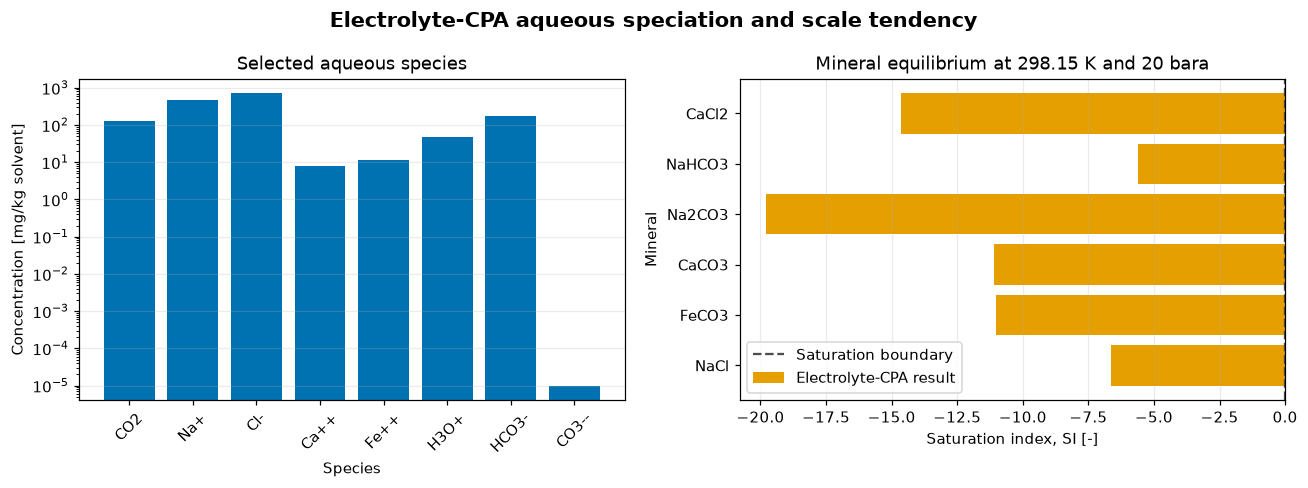

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    ion_table["Component"],
    ion_table["mg/kg solvent"],
    color=COLORS["blue"],
)
axes[0].set_yscale("log")
axes[0].set_title("Selected aqueous species")
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Concentration [mg/kg solvent]")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.25)

axes[1].barh(
    scale_table["Salt"],
    scale_table["saturation index [-]"],
    color=COLORS["orange"],
    label="Electrolyte-CPA result",
)
axes[1].axvline(
    0.0,
    color="#4D4D4D",
    linestyle="--",
    label="Saturation boundary",
)
axes[1].set_title("Mineral equilibrium at 298.15 K and 20 bara")
axes[1].set_xlabel("Saturation index, SI [-]")
axes[1].set_ylabel("Mineral")
axes[1].legend()
axes[1].grid(axis="x", alpha=0.25)

figure.suptitle(
    "Electrolyte-CPA aqueous speciation and scale tendency",
    fontsize=14,
    weight="bold",
)
figure.tight_layout()
plt.show()

The defined state is undersaturated for the reported salts. The dissolved carbon distribution
and activity coefficients show why pH and water chemistry must be solved together. A separate
fast screening model is useful when many project water analyses and operating cases must be
compared.

## Fast screening from a water analysis

The screening calculator accepts ion concentrations in mg/L, temperature in °C, absolute
pressure in bara, CO₂ partial pressure in bar, pH, and total dissolved solids (TDS) in mg/L.
It reports $SI$ for calcite, barite, celestite, anhydrite, and siderite.

The two synthetic analyses below represent a barium- and strontium-rich formation water and a
sulphate-rich injection water. They are intentionally incompatible so the mixing envelope is
clear. They are not tied to a specific asset.

In [10]:
formation_water = {
    "calcium": 1200.0,
    "barium": 150.0,
    "strontium": 800.0,
    "magnesium": 600.0,
    "sodium": 60000.0,
    "potassium": 1000.0,
    "chloride": 100000.0,
    "sulphate": 20.0,
    "bicarbonate": 800.0,
    "iron": 5.0,
    "tds": 100000.0,
}
injection_water = {
    "calcium": 400.0,
    "barium": 0.05,
    "strontium": 8.0,
    "magnesium": 1300.0,
    "sodium": 11000.0,
    "potassium": 400.0,
    "chloride": 19000.0,
    "sulphate": 2700.0,
    "bicarbonate": 140.0,
    "iron": 0.0,
    "tds": 35000.0,
}

water_table = pd.DataFrame(
    {
        "formation water [mg/L]": formation_water,
        "injection water [mg/L]": injection_water,
    }
)
print(water_table.to_string(float_format=lambda value: f"{value:.3f}"))

             formation water [mg/L]  injection water [mg/L]
calcium                    1200.000                 400.000
barium                      150.000                   0.050
strontium                   800.000                   8.000
magnesium                   600.000                1300.000
sodium                    60000.000               11000.000
potassium                  1000.000                 400.000
chloride                 100000.000               19000.000
sulphate                     20.000                2700.000
bicarbonate                 800.000                 140.000
iron                          5.000                   0.000
tds                      100000.000               35000.000


In [11]:
def calculate_scale_screen(
    chemistry,
    temperature_c,
    pressure_bara,
    ph_value,
    co2_partial_pressure_bar,
):
    calculator = ScalePredictionCalculator()
    calculator.setTemperatureCelsius(temperature_c)
    calculator.setPressureBara(pressure_bara)
    calculator.setCalciumConcentration(chemistry["calcium"])
    calculator.setBariumConcentration(chemistry["barium"])
    calculator.setStrontiumConcentration(chemistry["strontium"])
    calculator.setIronConcentration(chemistry["iron"])
    calculator.setMagnesiumConcentration(chemistry["magnesium"])
    calculator.setSodiumConcentration(chemistry["sodium"])
    calculator.setBicarbonateConcentration(chemistry["bicarbonate"])
    calculator.setSulphateConcentration(chemistry["sulphate"])
    calculator.setTotalDissolvedSolids(chemistry["tds"])
    calculator.setCO2PartialPressure(co2_partial_pressure_bar)
    calculator.setPH(ph_value)
    calculator.calculate()
    return {
        "CaCO3": float(calculator.getCaCO3SaturationIndex()),
        "BaSO4": float(calculator.getBaSO4SaturationIndex()),
        "SrSO4": float(calculator.getSrSO4SaturationIndex()),
        "CaSO4": float(calculator.getCaSO4SaturationIndex()),
        "FeCO3": float(calculator.getFeCO3SaturationIndex()),
    }


screening_chemistry = formation_water.copy()
screening_chemistry["sulphate"] = 2500.0
base_screen = calculate_scale_screen(
    screening_chemistry,
    temperature_c=60.0,
    pressure_bara=100.0,
    ph_value=6.3,
    co2_partial_pressure_bar=1.0,
)
base_screen_table = pd.DataFrame(
    {
        "mineral": list(base_screen.keys()),
        "saturation index, SI [-]": list(base_screen.values()),
    }
)
print(
    base_screen_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

mineral  saturation index, SI [-]
  CaCO3                   -1.1349
  BaSO4                    3.3268
  SrSO4                   -0.3268
  CaSO4                   -0.4670
  FeCO3                   -3.7810


The incompatible screening chemistry is strongly supersaturated with respect to barite.
Positive $SI$ identifies tendency only; it does not state deposited mass or treatment dose.
Sensitivity analysis reveals which measurements and operating changes control the result.

## pH and sulphate sensitivity

Carbonate speciation changes strongly with pH, while barite tendency responds to the coexistence
of barium and sulphate. The pH sweep holds all analytical concentrations fixed. The sulphate
sweep holds pH and barium fixed. These are controlled numerical experiments rather than
predictions of a coupled field trajectory.

In [12]:
ph_values = np.linspace(5.5, 7.5, 17)
caco3_si_values = []
for ph_value in ph_values:
    result = calculate_scale_screen(
        formation_water,
        temperature_c=40.0,
        pressure_bara=100.0,
        ph_value=float(ph_value),
        co2_partial_pressure_bar=1.0,
    )
    caco3_si_values.append(result["CaCO3"])

sulphate_values = np.geomspace(5.0, 2700.0, 17)
barite_si_values = []
for sulphate_value in sulphate_values:
    chemistry = formation_water.copy()
    chemistry["sulphate"] = float(sulphate_value)
    result = calculate_scale_screen(
        chemistry,
        temperature_c=40.0,
        pressure_bara=100.0,
        ph_value=6.3,
        co2_partial_pressure_bar=1.0,
    )
    barite_si_values.append(result["BaSO4"])

print(
    "CaCO3 SI range over pH sweep: "
    f"{min(caco3_si_values):.3f} to {max(caco3_si_values):.3f}"
)
print(
    "BaSO4 SI range over sulphate sweep: "
    f"{min(barite_si_values):.3f} to {max(barite_si_values):.3f}"
)

CaCO3 SI range over pH sweep: -2.035 to -0.035
BaSO4 SI range over sulphate sweep: 0.705 to 3.586


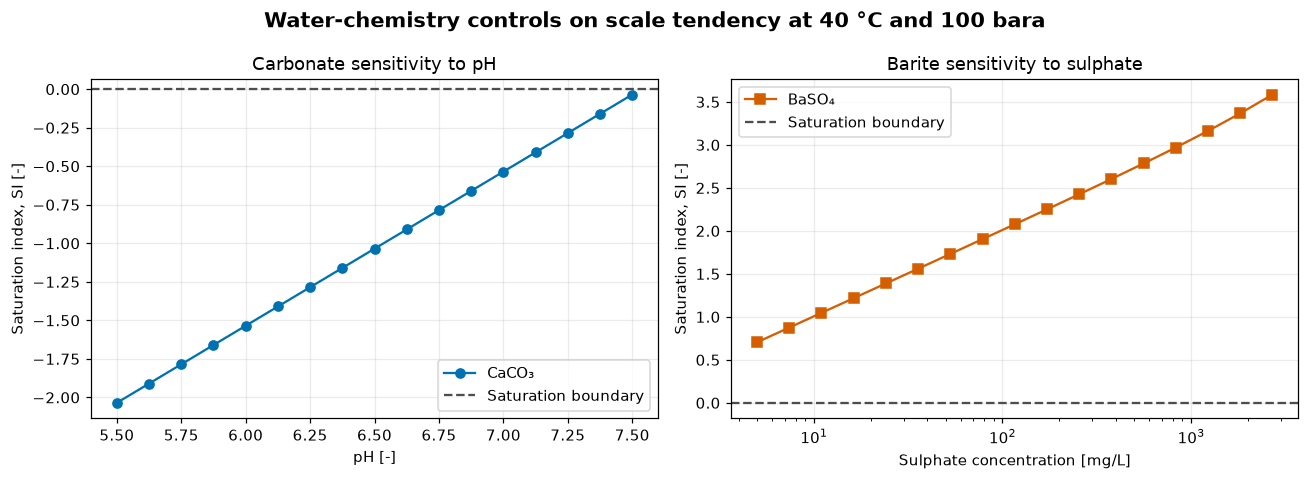

In [13]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.4))

axes[0].plot(
    ph_values,
    caco3_si_values,
    marker="o",
    color=COLORS["blue"],
    label="CaCO₃",
)
axes[0].axhline(
    0.0,
    color="#4D4D4D",
    linestyle="--",
    label="Saturation boundary",
)
axes[0].set_title("Carbonate sensitivity to pH")
axes[0].set_xlabel("pH [-]")
axes[0].set_ylabel("Saturation index, SI [-]")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].semilogx(
    sulphate_values,
    barite_si_values,
    marker="s",
    color=COLORS["red"],
    label="BaSO₄",
)
axes[1].axhline(
    0.0,
    color="#4D4D4D",
    linestyle="--",
    label="Saturation boundary",
)
axes[1].set_title("Barite sensitivity to sulphate")
axes[1].set_xlabel("Sulphate concentration [mg/L]")
axes[1].set_ylabel("Saturation index, SI [-]")
axes[1].legend()
axes[1].grid(alpha=0.25)

figure.suptitle(
    "Water-chemistry controls on scale tendency at 40 °C and 100 bara",
    fontsize=14,
    weight="bold",
)
figure.tight_layout()
plt.show()

The carbonate index rises with pH because more dissolved inorganic carbon is available as
carbonate ion. The barite index rises as sulphate becomes available to the barium-rich water.
These monotonic trends are also used as validation checks later.

## Incompatible-water mixing

For fraction $f$ of formation water A and fraction $1-f$ of injection water B, each analytical
concentration is linearly mixed:

$$
C_i(f) = f C_{i,A} + (1-f) C_{i,B}
$$

The activity and solubility calculations remain nonlinear, so the worst saturation index can
occur between the two end members. Twenty-one mixing points are evaluated at 40 °C, 100 bara,
and pH 6.3.

In [14]:
formation_brine = BrineComposition(
    formation_water["calcium"],
    formation_water["barium"],
    formation_water["strontium"],
    formation_water["magnesium"],
    formation_water["sodium"],
    formation_water["potassium"],
    formation_water["chloride"],
    formation_water["sulphate"],
    formation_water["bicarbonate"],
)
injection_brine = BrineComposition(
    injection_water["calcium"],
    injection_water["barium"],
    injection_water["strontium"],
    injection_water["magnesium"],
    injection_water["sodium"],
    injection_water["potassium"],
    injection_water["chloride"],
    injection_water["sulphate"],
    injection_water["bicarbonate"],
)

mixing_evaluator = BrineMixingScaleEvaluator(
    formation_brine,
    injection_brine,
)
mixing_evaluator.setConditions(40.0, 100.0)
mixing_evaluator.setPH(6.3)
mixing_evaluator.setSteps(21)
mixing_evaluator.evaluate()

mixing_report = json.loads(str(mixing_evaluator.toJson()))
mixing_table = pd.DataFrame(mixing_report["points"])
mixing_table["formation-water fraction [-]"] = mixing_table["fractionA"]
print(
    "Worst mineral: "
    f"{mixing_evaluator.getWorstMineral()}"
)
print(
    "Worst formation-water fraction: "
    f"{mixing_evaluator.getWorstFractionA():.3f}"
)
print(f"Worst SI: {mixing_evaluator.getWorstSI():.3f}")

Worst mineral: BaSO4
Worst formation-water fraction: 0.850
Worst SI: 4.909


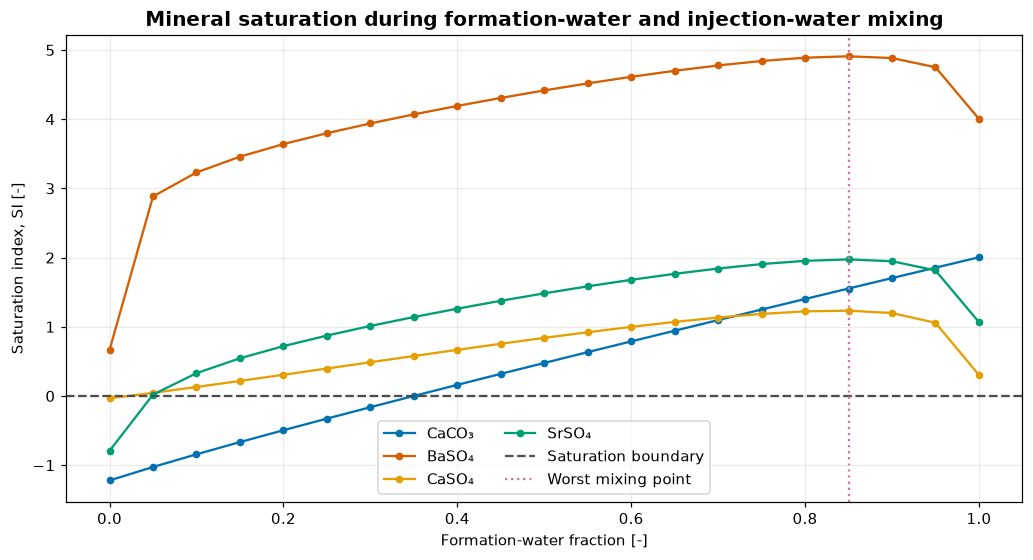

In [15]:
figure, axis = plt.subplots(figsize=(9.5, 5.2))
mineral_columns = {
    "CaCO₃": "caco3SI",
    "BaSO₄": "baso4SI",
    "CaSO₄": "caso4SI",
    "SrSO₄": "srso4SI",
}
line_colors = [
    COLORS["blue"],
    COLORS["red"],
    COLORS["orange"],
    COLORS["green"],
]

for color, (mineral, column) in zip(line_colors, mineral_columns.items()):
    axis.plot(
        mixing_table["formation-water fraction [-]"],
        mixing_table[column],
        marker="o",
        markersize=4,
        color=color,
        label=mineral,
    )

axis.axhline(
    0.0,
    color="#4D4D4D",
    linestyle="--",
    label="Saturation boundary",
)
axis.axvline(
    float(mixing_evaluator.getWorstFractionA()),
    color=COLORS["purple"],
    linestyle=":",
    label="Worst mixing point",
)
axis.set_title(
    "Mineral saturation during formation-water and injection-water mixing",
    fontsize=13,
    weight="bold",
)
axis.set_xlabel("Formation-water fraction [-]")
axis.set_ylabel("Saturation index, SI [-]")
axis.legend(ncol=2)
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

The worst result occurs at an intermediate water fraction, where formation-water barium and
injection-water sulphate coexist. This is why end-member water analyses alone do not define a
compatibility envelope. The calculated maximum is a screening signal for water management and
laboratory testing.

## Scale tendency along a flowline trajectory

The scale-profile object interpolates temperature and pressure between inlet and outlet
conditions and recalculates the mineral indices. The water chemistry is the worst mixing
composition identified above. Distance is represented by a 20 km engineering coordinate.

This profile is a thermodynamic screen. It assumes fixed analytical ion concentrations and pH
along the line; precipitation, dissolution, and inhibitor depletion are not coupled into this
part of the calculation.

In [16]:
worst_fraction = float(mixing_evaluator.getWorstFractionA())


def blend_concentration(name):
    return (
        worst_fraction * formation_water[name]
        + (1.0 - worst_fraction) * injection_water[name]
    )


worst_mix = {
    name: blend_concentration(name)
    for name in formation_water
}

scale_profile = FlowlineScaleProfile()
scale_profile.setWaterChemistry(
    worst_mix["calcium"],
    worst_mix["barium"],
    worst_mix["strontium"],
    worst_mix["iron"],
    worst_mix["bicarbonate"],
    worst_mix["sulphate"],
    worst_mix["tds"],
    1.0,
    6.3,
)
scale_profile.setMgNaConcentrations(
    worst_mix["magnesium"],
    worst_mix["sodium"],
)
scale_profile.setInletConditions(80.0, 200.0)
scale_profile.setOutletConditions(20.0, 100.0)
scale_profile.setNumberOfSegments(15)
scale_profile.setAutoPH(False)
scale_profile.calculate()

profile_report = json.loads(str(scale_profile.toJson()))
profile_table = pd.DataFrame(profile_report["segmentResults"])
profile_table["distance [km]"] = (
    20.0 * profile_table["distanceFraction"]
)
print(
    profile_table[
        [
            "distance [km]",
            "temperatureC",
            "pressureBar",
            "SI_BaSO4",
            "SI_SrSO4",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

 distance [km]  temperatureC  pressureBar  SI_BaSO4  SI_SrSO4
         0.000        80.000      200.000     2.338    -2.013
         1.333        76.000      193.333     2.359    -1.852
         2.667        72.000      186.667     2.384    -1.688
         4.000        68.000      180.000     2.413    -1.521
         5.333        64.000      173.333     2.445    -1.349
         6.667        60.000      166.667     2.480    -1.174
         8.000        56.000      160.000     2.519    -0.994
         9.333        52.000      153.333     2.563    -0.810
        10.667        48.000      146.667     2.610    -0.621
        12.000        44.000      140.000     2.662    -0.428
        13.333        40.000      133.333     2.718    -0.231
        14.667        36.000      126.667     2.780    -0.028
        16.000        32.000      120.000     2.846     0.180
        17.333        28.000      113.333     2.918     0.394
        18.667        24.000      106.667     2.995     0.613
        

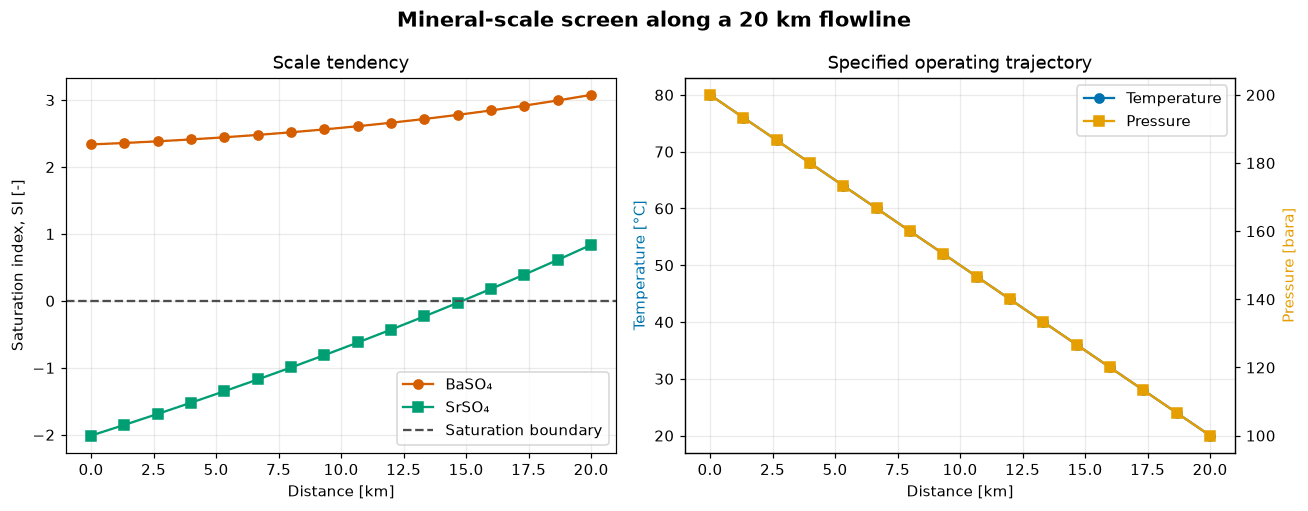

In [17]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.7))

axes[0].plot(
    profile_table["distance [km]"],
    profile_table["SI_BaSO4"],
    color=COLORS["red"],
    marker="o",
    label="BaSO₄",
)
axes[0].plot(
    profile_table["distance [km]"],
    profile_table["SI_SrSO4"],
    color=COLORS["green"],
    marker="s",
    label="SrSO₄",
)
axes[0].axhline(
    0.0,
    color="#4D4D4D",
    linestyle="--",
    label="Saturation boundary",
)
axes[0].set_title("Scale tendency")
axes[0].set_xlabel("Distance [km]")
axes[0].set_ylabel("Saturation index, SI [-]")
axes[0].legend()
axes[0].grid(alpha=0.25)

temperature_axis = axes[1]
pressure_axis = temperature_axis.twinx()
temperature_axis.plot(
    profile_table["distance [km]"],
    profile_table["temperatureC"],
    color=COLORS["blue"],
    marker="o",
    label="Temperature",
)
pressure_axis.plot(
    profile_table["distance [km]"],
    profile_table["pressureBar"],
    color=COLORS["orange"],
    marker="s",
    label="Pressure",
)
temperature_axis.set_title("Specified operating trajectory")
temperature_axis.set_xlabel("Distance [km]")
temperature_axis.set_ylabel("Temperature [°C]", color=COLORS["blue"])
pressure_axis.set_ylabel("Pressure [bara]", color=COLORS["orange"])
temperature_axis.grid(alpha=0.25)

lines_left, labels_left = temperature_axis.get_legend_handles_labels()
lines_right, labels_right = pressure_axis.get_legend_handles_labels()
temperature_axis.legend(
    lines_left + lines_right,
    labels_left + labels_right,
    loc="best",
)

figure.suptitle(
    "Mineral-scale screen along a 20 km flowline",
    fontsize=14,
    weight="bold",
)
figure.tight_layout()
plt.show()

Barite remains the dominant thermodynamic risk and increases toward the colder outlet in this
screen. Celestite crosses the saturation boundary along the line. The location of the maximum
matters for sampling, inhibitor injection, inspection, and water-management decisions.

## Inhibitor-dose assessment

The inhibitor model evaluates a phosphonate treatment against the worst barite saturation
ratio. Available dose is active concentration in mg/L. The model reports minimum inhibitor
concentration, a recommended dose with margin, efficiency, adequacy, and warnings.

The result is a screening estimate. Product-specific dynamic tube-blocking tests, adsorption,
partitioning, residence time, produced-solids effects, and residual analysis remain necessary.

In [18]:
worst_saturation_ratio = 10.0 ** float(
    mixing_evaluator.getWorstSI()
)
available_doses = np.arange(0.0, 65.0, 5.0)
inhibitor_rows = []

for available_dose in available_doses:
    inhibitor = ScaleInhibitorPerformance()
    inhibitor.setScaleType(ScaleType.BASO4)
    inhibitor.setInhibitorChemistry(
        InhibitorChemistry.PHOSPHONATE
    )
    inhibitor.setTemperatureCelsius(40.0)
    inhibitor.setSaturationRatio(worst_saturation_ratio)
    inhibitor.setTdsMgL(worst_mix["tds"])
    inhibitor.setCalciumMgL(worst_mix["calcium"])
    inhibitor.setAvailableDoseMgL(float(available_dose))
    inhibitor.evaluate()
    inhibitor_rows.append(
        {
            "available dose [mg/L]": float(available_dose),
            "efficiency [-]": float(inhibitor.getEfficiency()),
            "minimum dose [mg/L]": float(
                inhibitor.getMinimumInhibitorConcentrationMgL()
            ),
            "recommended dose [mg/L]": float(
                inhibitor.getRecommendedDoseMgL()
            ),
            "adequate": bool(inhibitor.isAdequate()),
        }
    )

inhibitor_table = pd.DataFrame(inhibitor_rows)
print(
    inhibitor_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

 available dose [mg/L]  efficiency [-]  minimum dose [mg/L]  recommended dose [mg/L]  adequate
                 0.000           0.000               30.153                   45.229     False
                 5.000           0.141               30.153                   45.229     False
                10.000           0.282               30.153                   45.229     False
                15.000           0.423               30.153                   45.229     False
                20.000           0.564               30.153                   45.229     False
                25.000           0.705               30.153                   45.229     False
                30.000           0.846               30.153                   45.229     False
                35.000           0.872               30.153                   45.229      True
                40.000           0.892               30.153                   45.229      True
                45.000           0.908            

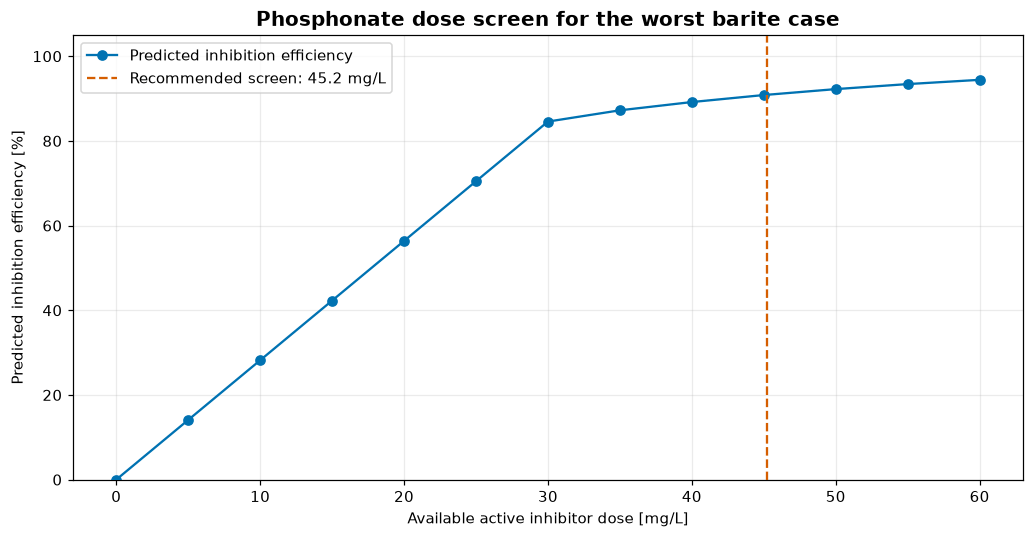

In [19]:
figure, axis = plt.subplots(figsize=(9.5, 5.0))
axis.plot(
    inhibitor_table["available dose [mg/L]"],
    100.0 * inhibitor_table["efficiency [-]"],
    marker="o",
    color=COLORS["blue"],
    label="Predicted inhibition efficiency",
)
recommended_dose = float(
    inhibitor_table["recommended dose [mg/L]"].iloc[0]
)
axis.axvline(
    recommended_dose,
    color=COLORS["red"],
    linestyle="--",
    label=f"Recommended screen: {recommended_dose:.1f} mg/L",
)
axis.set_title(
    "Phosphonate dose screen for the worst barite case",
    fontsize=13,
    weight="bold",
)
axis.set_xlabel("Available active inhibitor dose [mg/L]")
axis.set_ylabel("Predicted inhibition efficiency [%]")
axis.set_ylim(0.0, 105.0)
axis.legend()
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

The screening model requires a substantial dose because the synthetic mixed water is extremely
supersaturated. When chemical control becomes demanding, water exclusion, segregation,
desulphation, solids management, pigging, and materials or geometry changes should be assessed
together with chemical treatment.

## Final application: coupled production fluid, pipe, and deposition

A reusable process chain is now assembled:

`CPA production fluid → Stream → PipeBeggsAndBrills → ScaleDepositionAccumulator → closed-loop solver`

The 10 km line has a 0.25 m internal diameter, rises 50 m, cools against a 5 °C environment,
and carries 25 kg/s. The deposition scenario uses a calcium/bicarbonate brine at pH 7.5 with
0.1 bar CO₂ partial pressure, one year of service, and 70% inhibitor efficiency.

The thickness relation used by the accumulator is conceptually

$$
\delta = \frac{m_s}{\rho_s A_w}
$$

where $\delta$ is deposit thickness in m, $m_s$ is deposited mass in kg, $\rho_s$ is scale
density in kg/m³, and $A_w$ is wetted wall area in m². The base deposition rate is an explicit
scenario parameter, not a universal kinetic constant.

In [20]:
production_fluid = fluid(
    "cpa",
    temperature=333.15,
    pressure=120.0,
)
production_composition = {
    "nitrogen": 1.0,
    "CO2": 2.0,
    "methane": 82.0,
    "ethane": 5.0,
    "propane": 3.0,
    "n-heptane": 6.0,
    "water": 1.0,
}
for component_name, molar_amount in production_composition.items():
    production_fluid.addComponent(
        component_name,
        molar_amount,
    )

production_fluid.setMixingRule(10)
production_fluid.setMultiPhaseCheck(True)

production_feed = stream(
    "scale-prone production feed",
    production_fluid,
)
production_feed.setFlowRate(25.0, "kg/sec")
production_feed.run()

production_flowline = beggs_brill_pipe(
    "cooled production flowline",
    production_feed,
    length=10000.0,
    diameter=0.25,
    elevation=50.0,
    roughness=5.0e-5,
)
production_flowline.setNumberOfIncrements(10)
production_flowline.setConstantSurfaceTemperature(5.0, "C")
production_flowline.setHeatTransferCoefficient(15.0)
production_flowline.run()

inlet_pressure = production_feed.getPressure("bara")
outlet_pressure = production_flowline.getOutletStream().getPressure("bara")
inlet_temperature = production_feed.getTemperature("C")
outlet_temperature = production_flowline.getOutletStream().getTemperature("C")

print(f"Inlet pressure: {inlet_pressure:.3f} bara")
print(f"Outlet pressure: {outlet_pressure:.3f} bara")
print(f"Pressure drop: {inlet_pressure - outlet_pressure:.3f} bar")
print(f"Inlet temperature: {inlet_temperature:.3f} °C")
print(f"Outlet temperature: {outlet_temperature:.3f} °C")

Inlet pressure: 120.000 bara
Outlet pressure: 111.236 bara
Pressure drop: 8.764 bar
Inlet temperature: 60.000 °C
Outlet temperature: 16.563 °C


In [21]:
deposition = ScaleDepositionAccumulator(production_flowline)
deposition.setBrineChemistry(
    1200.0,
    800.0,
    2500.0,
    150.0,
    60000.0,
    100000.0,
)
deposition.setpHAndCo2(7.5, 0.1)
deposition.setInhibitorEfficiency(0.70)
deposition.setServiceYears(1.0)
deposition.setScaleDensity(2700.0)
deposition.setBaseRate(0.5)
deposition.evaluate()

closed_loop_solver = ClosedLoopDepositionSolver(
    production_flowline,
    deposition,
)
closed_loop_solver.setToleranceM(1.0e-5)
closed_loop_solver.setMaxIterations(8)
closed_loop_solver.solve()

print(
    "Total deposited mass after one year: "
    f"{deposition.getTotalDepositionMassKg():.3f} kg"
)
print(
    "Maximum deposit thickness: "
    f"{deposition.getMaxThicknessMm():.6f} mm"
)
print(
    "Final effective diameter: "
    f"{closed_loop_solver.getFinalEffectiveDiameterM():.9f} m"
)
print(
    "Closed-loop iterations: "
    f"{closed_loop_solver.getIterationsTaken()}"
)
print(f"Closed-loop converged: {closed_loop_solver.isConverged()}")

Total deposited mass after one year: 14.452 kg
Maximum deposit thickness: 0.006291 mm
Final effective diameter: 0.249987418 m
Closed-loop iterations: 3
Closed-loop converged: True


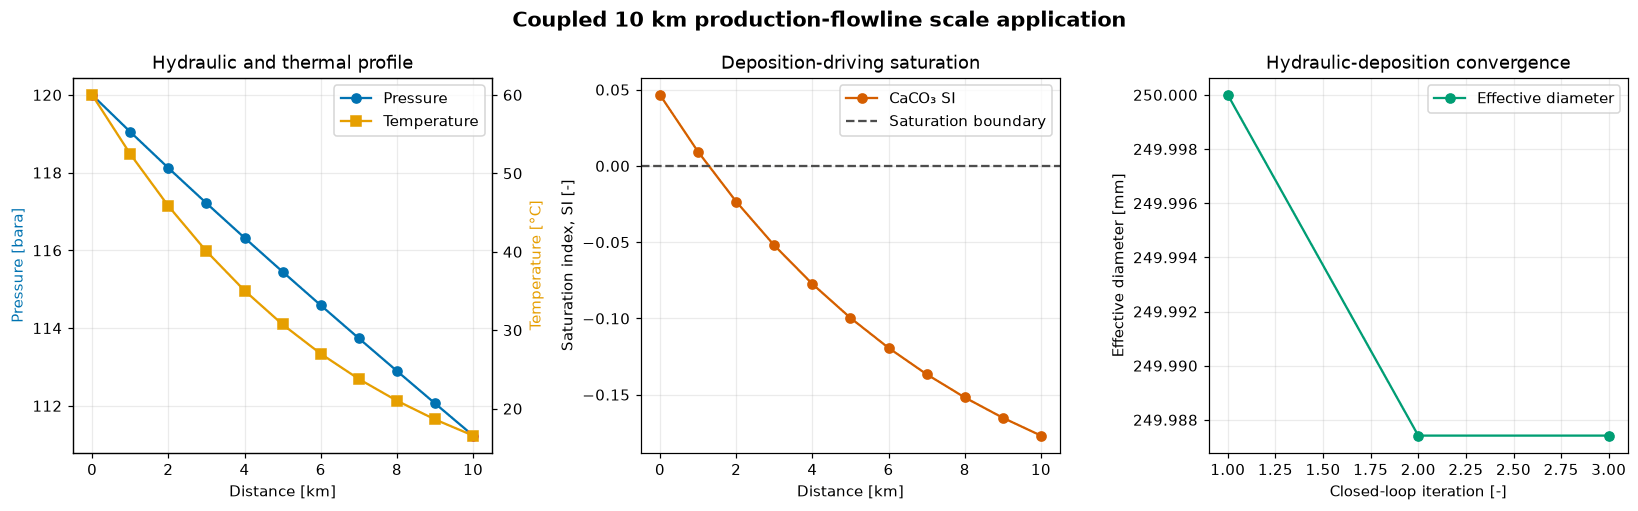

In [22]:
length_profile_km = np.asarray(
    list(production_flowline.getLengthProfile()),
    dtype=float,
) / 1000.0
pressure_profile = np.asarray(
    list(production_flowline.getPressureProfile()),
    dtype=float,
)
temperature_profile_c = np.asarray(
    list(production_flowline.getTemperatureProfile()),
    dtype=float,
) - 273.15
deposition_si = np.asarray(
    list(deposition.getSegmentSaturationIndex()),
    dtype=float,
)
thickness_profile_mm = np.asarray(
    list(deposition.getSegmentThicknessMm()),
    dtype=float,
)
diameter_history_mm = 1000.0 * np.asarray(
    list(closed_loop_solver.getDiameterHistoryM()),
    dtype=float,
)

figure, axes = plt.subplots(1, 3, figsize=(15, 4.7))

pressure_axis = axes[0]
temperature_axis = pressure_axis.twinx()
pressure_axis.plot(
    length_profile_km,
    pressure_profile,
    color=COLORS["blue"],
    marker="o",
    label="Pressure",
)
temperature_axis.plot(
    length_profile_km,
    temperature_profile_c,
    color=COLORS["orange"],
    marker="s",
    label="Temperature",
)
pressure_axis.set_title("Hydraulic and thermal profile")
pressure_axis.set_xlabel("Distance [km]")
pressure_axis.set_ylabel("Pressure [bara]", color=COLORS["blue"])
temperature_axis.set_ylabel(
    "Temperature [°C]",
    color=COLORS["orange"],
)
lines_a, labels_a = pressure_axis.get_legend_handles_labels()
lines_b, labels_b = temperature_axis.get_legend_handles_labels()
pressure_axis.legend(lines_a + lines_b, labels_a + labels_b)
pressure_axis.grid(alpha=0.25)

axes[1].plot(
    length_profile_km,
    deposition_si,
    color=COLORS["red"],
    marker="o",
    label="CaCO₃ SI",
)
axes[1].axhline(
    0.0,
    color="#4D4D4D",
    linestyle="--",
    label="Saturation boundary",
)
axes[1].set_title("Deposition-driving saturation")
axes[1].set_xlabel("Distance [km]")
axes[1].set_ylabel("Saturation index, SI [-]")
axes[1].legend()
axes[1].grid(alpha=0.25)

iteration_numbers = np.arange(1, len(diameter_history_mm) + 1)
axes[2].plot(
    iteration_numbers,
    diameter_history_mm,
    color=COLORS["green"],
    marker="o",
    label="Effective diameter",
)
axes[2].set_title("Hydraulic-deposition convergence")
axes[2].set_xlabel("Closed-loop iteration [-]")
axes[2].set_ylabel("Effective diameter [mm]")
axes[2].ticklabel_format(
    axis="y",
    style="plain",
    useOffset=False,
)
axes[2].legend()
axes[2].grid(alpha=0.25)

figure.suptitle(
    "Coupled 10 km production-flowline scale application",
    fontsize=14,
    weight="bold",
)
figure.tight_layout()
plt.show()

The flowline cools and loses pressure in the expected direction. The stated carbonate scenario
is slightly supersaturated near the inlet, then becomes undersaturated as conditions evolve.
Deposition is therefore concentrated near the inlet. After one year, the calculated thickness
is small relative to the 250 mm bore and the hydraulic feedback converges rapidly.

This is an engineering workflow demonstration. A project prediction must calibrate deposition
rate, inhibitor efficiency, water cut, wetting, residence time, and removal mechanisms against
field or laboratory evidence.

## Verification checks

The checks cover runtime provenance, phase existence, finite properties, equilibrium-table
structure, expected sensitivity trends, incompatible-water behavior, profile size and
direction, inhibitor response, process pressure and temperature direction, non-negative
deposition, and closed-loop convergence.

In [23]:
checks = {
    "NeqSim version recorded": len(neqsim_version) > 0,
    "two thermodynamic phases": electrolyte_fluid.getNumberOfPhases() == 2,
    "aqueous phase exists": electrolyte_fluid.hasPhaseType("aqueous"),
    "gas phase exists": electrolyte_fluid.hasPhaseType("gas"),
    "finite aqueous pH": np.isfinite(
        electrolyte_fluid.getPhase("aqueous").getpH()
    ),
    "positive gas density": phase_table.loc[
        phase_table["phase"] == "gas",
        "density [kg/m³]",
    ].iloc[0]
    > 0.0,
    "positive aqueous density": phase_table.loc[
        phase_table["phase"] == "aqueous",
        "density [kg/m³]",
    ].iloc[0]
    > 0.0,
    "ion table populated": len(ion_table) >= 8,
    "scale table populated": len(scale_table) >= 5,
    "positive saturation ratios": bool(
        (scale_table["saturation ratio [-]"] >= 0.0).all()
    ),
    "barite screen positive": base_screen["BaSO4"] > 0.0,
    "carbonate SI rises with pH": bool(
        np.all(np.diff(caco3_si_values) > 0.0)
    ),
    "barite SI rises with sulphate": bool(
        np.all(np.diff(barite_si_values) > 0.0)
    ),
    "mixing sweep has 21 points": len(mixing_table) == 21,
    "worst mixing point is internal": 0.0 < worst_fraction < 1.0,
    "barite is worst mixed-water mineral": str(
        mixing_evaluator.getWorstMineral()
    )
    == "BaSO4",
    "mixed-water SI exceeds endpoints": float(
        mixing_evaluator.getWorstSI()
    )
    > max(
        mixing_table["baso4SI"].iloc[0],
        mixing_table["baso4SI"].iloc[-1],
    ),
    "profile has 16 locations": len(profile_table) == 16,
    "profile pressure decreases": bool(
        np.all(np.diff(profile_table["pressureBar"]) < 0.0)
    ),
    "profile temperature decreases": bool(
        np.all(np.diff(profile_table["temperatureC"]) < 0.0)
    ),
    "inhibitor efficiency rises with dose": bool(
        np.all(np.diff(inhibitor_table["efficiency [-]"]) >= 0.0)
    ),
    "highest dose is adequate": bool(
        inhibitor_table["adequate"].iloc[-1]
    ),
    "pipe pressure decreases": outlet_pressure < inlet_pressure,
    "pipe temperature decreases": outlet_temperature < inlet_temperature,
    "deposition mass is non-negative": (
        deposition.getTotalDepositionMassKg() >= 0.0
    ),
    "thickness is smaller than radius": (
        deposition.getMaxThicknessMm() < 125.0
    ),
    "closed loop converged": bool(
        closed_loop_solver.isConverged()
    ),
}

failed_checks = [
    name
    for name, passed in checks.items()
    if not passed
]
assert not failed_checks, f"Failed checks: {failed_checks}"

print(f"All {len(checks)} engineering checks passed.")
for name in checks:
    print(f"PASS - {name}")

All 27 engineering checks passed.
PASS - NeqSim version recorded
PASS - two thermodynamic phases
PASS - aqueous phase exists
PASS - gas phase exists
PASS - finite aqueous pH
PASS - positive gas density
PASS - positive aqueous density
PASS - ion table populated
PASS - scale table populated
PASS - positive saturation ratios
PASS - barite screen positive
PASS - carbonate SI rises with pH
PASS - barite SI rises with sulphate
PASS - mixing sweep has 21 points
PASS - worst mixing point is internal
PASS - barite is worst mixed-water mineral
PASS - mixed-water SI exceeds endpoints
PASS - profile has 16 locations
PASS - profile pressure decreases
PASS - profile temperature decreases
PASS - inhibitor efficiency rises with dose
PASS - highest dose is adequate
PASS - pipe pressure decreases
PASS - pipe temperature decreases
PASS - deposition mass is non-negative
PASS - thickness is smaller than radius
PASS - closed loop converged


## Troubleshooting

- **No aqueous phase:** increase water content, enable multiphase checking where applicable,
  and confirm that the requested state supports an aqueous phase.
- **Unknown ion name:** use NeqSim component names such as `Na+`, `Cl-`, `Ca++`, `Ba++`,
  `Sr++`, and `SO4--`.
- **Charge imbalance:** verify the laboratory analysis, ion valence, unit basis, alkalinity
  interpretation, and electroneutrality before trusting a scale result.
- **Positive SI but no field deposition:** check kinetics, residence time, surfaces, inhibitor
  residual, solids, mixing location, and whether precipitation occurred upstream.
- **Unexpected pH response:** confirm whether pH is measured at laboratory or process
  conditions and whether CO₂ partial pressure and alkalinity are consistent.
- **Pipeline non-convergence:** begin with a nearby flow rate, realistic diameter, explicit
  pressure and temperature, and moderate segment count; then increase resolution.

## Limitations and applicability

- Saturation index quantifies thermodynamic tendency, not deposition rate.
- Analytical water data must be internally consistent and representative of process conditions.
- The fast screening classes use engineering activity and solubility correlations; the
  Electrolyte-CPA calculation resolves a more detailed thermodynamic state.
- The linear mixing calculation does not model precipitation consuming ions during the sweep.
- The flowline screening profile holds analytical chemistry and pH fixed.
- The deposition rate, inhibitor efficiency, wall wetting, and scale density are scenario
  assumptions and must be calibrated.
- Erosion, solids transport, biofilm, corrosion products, and mechanical removal are outside
  this tutorial.

Use this workflow for screening, sensitivity analysis, experiment planning, and integration
with a wider NeqSim process model. Do not use it as the sole basis for chemical qualification
or integrity decisions.

## Summary

This notebook demonstrated:

- Electrolyte-CPA gas-aqueous equilibrium and ionic speciation;
- mineral saturation ratio and saturation index calculations;
- pH and sulphate sensitivity;
- incompatible formation-water and injection-water mixing;
- temperature and pressure dependent flowline screening;
- phosphonate dose assessment; and
- a connected production-fluid, stream, multiphase-pipe, deposition, and closed-loop workflow.

The synthetic mixing study identified barite as the controlling risk at an internal mixing
fraction. The final pipe case produced a small, inlet-weighted carbonate deposit and converged
with negligible bore reduction over the stated one-year scenario.

## Further exercises

1. Replace the synthetic water analyses with charge-balanced laboratory data and propagate
   analytical uncertainty.
2. Compare fixed pH with automatic CO₂-dependent pH in `FlowlineScaleProfile`.
3. Repeat the mixing envelope at several temperatures and locate the global worst case.
4. Compare phosphonate, polymaleate, and polyacrylate dose screens.
5. Vary water cut, pipe diameter, heat-transfer coefficient, and service years in the final
   application.
6. Couple deposition with inspection limits and a pigging or chemical-treatment schedule.
7. Add a mass-balance model that removes precipitated ions from downstream water chemistry.

## References

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim `ScalePredictionCalculator` source and API documentation](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/pvtsimulation/flowassurance/ScalePredictionCalculator.java)
- [NeqSim `BrineMixingScaleEvaluator` source and API documentation](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/chemistry/scale/BrineMixingScaleEvaluator.java)
- [NeqSim `CheckScalePotential` source and thermodynamic definition](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/thermodynamicoperations/flashops/saturationops/CheckScalePotential.java)
- Plummer, L. N., and Busenberg, E. (1982), calcite solubility in the
  CaCO₃-CO₂-H₂O system, *Geochimica et Cosmochimica Acta*, 46, 1011–1040.
- AMPP/NACE TM0374, laboratory screening tests for scale inhibitors.

Always check the version and validity range of the selected correlation, laboratory method,
water analysis, and company engineering practice before project use.